In [1]:
from sage.matrix.constructor import Matrix
from sage.rings.rational_field import QQ

class bMatrix:
    def __init__(self, dim:tuple, position):
        """
        Initializes a matrix of size (nrows x ncols) with a single entry of 1 at 'position'.
        
        :param nrows: Number of rows
        :param ncols: Number of columns
        :param position: A tuple (i, j) specifying the position of the 1-entry
        """
        nrows=dim[0]
        ncols=dim[1]
        # Create a zero matrix first
        self.mat = Matrix(QQ, nrows, ncols, 0)
        
        # Ensure position is within bounds
        if len(position)>0:
            if not (0 <= position[0] < nrows and 0 <= position[1] < ncols):
                raise ValueError("Position is out of bounds.")
            
            # Set the single 1-entry
            self.mat[position] = 1

    def is_valid(self):
        """
        Checks if the matrix has exactly one entry as 1 and all others are 0.
        """
        return sum(self.mat.list()) == 1  # Sum of entries should be exactly 1

    def __mul__(self, other):
        """
        Defines the multiplication operation for OneEntryMatrix.
        """
        if isinstance(other, bMatrix):
            return self.mat * other.mat
        else:
            raise TypeError("Unsupported operand type(s) for *: 'OneEntryMatrix' and '{}'".format(type(other).__name__))
    def __add__(self, other):
        """
        Defines the addition operation for OneEntryMatrix.
        """
        if isinstance(other, bMatrix):
            return self.mat + other.mat
        else:
            raise TypeError("Unsupported operand type(s) for +: 'OneEntryMatrix' and '{}'".format(type(other).__name__))
    def __sub__(self, other):
        """
        Defines the subtraction operation for OneEntryMatrix.
        """
        if isinstance(other, bMatrix):
            return self.mat - other.mat
        else:
            raise TypeError("Unsupported operand type(s) for -: 'OneEntryMatrix' and '{}'".format(type(other).__name__))
    def __eq__(self, other):
        """
        Defines the equality operation for OneEntryMatrix.
        """
        if isinstance(other, bMatrix):
            return self.mat == other.mat
        else:
            raise TypeError("Unsupported operand type(s) for ==: 'OneEntryMatrix' and '{}'".format(type(other).__name__))

    def __repr__(self):
        return repr(self.mat)


# Graph Magma Class 

In [119]:
class graphMagma:
    from sage.matrix.constructor import block_matrix, zero_matrix, identity_matrix, matrix
    from sage.rings.integer_ring import ZZ
    from sage.all import var
    
    #Create a global variable to store the generators
    generators = []
    Inc = matrix(ZZ, 0, 0, [])
    multiplication_table = matrix(SR,0,0,[])
    #Create a global variable to store the graph
    graph = []
    def __init__(self, graph:list=[], value_number:int=2):
        self.value_number = value_number
        self.params_for_1_value = []
        if value_number < 2:
            self.graph = []
            params=input("Please enter the parameters (t,p_1,...,p_s) in respective order for a graph of the form N_t U N_p_1 \oplus K_1 U ... U N_p_s \oplus K_1:")
            for p in params.split(','):
                self.params_for_1_value.append(int(p.strip()))
            if 0 in self.params_for_1_value[1:]:
                raise ValueError("Parameters other than t must be positive integers.")
            if len(self.params_for_1_value) < 1:
                raise ValueError("At least one parameter must be provided.")
            if self.params_for_1_value[0] >= 1:
                self.graph.append([('N', self.params_for_1_value[0])])
            for p in self.params_for_1_value[1:]:
                self.graph.append([('N', p), ('K', 1)])
            print("The graph magma is constructed on the following graph: ", self.graph)
        else:
            self.graph = graph
        self.generators = self.getGenerators()
        self.Inc = self.getIncidenceMatrix()
        self.multiplication_table = self.getMultiplicationTable()
    def getGenerators(self):
        self.generators = []
        if self.value_number == 2:
            for i in range(len(self.graph)):
                for j in range(self.graph[i][1]):
                    self.generators.append(var(f"a_{i}_{j}", latex_name=fr"\alpha_{{{i},{j}}}"))
        elif self.value_number == 1:
            if self.params_for_1_value[0] >= 1:
                for j in range(self.params_for_1_value[0]):
                    self.generators.append(var(f"v_{j}", latex_name=fr"v_{{{j}}}"))
            for i in range(1,len(self.params_for_1_value)):
                p = self.params_for_1_value[i]
                self.generators.append(var(f"w_{i}", latex_name=fr"w_{{{i}}}"))
                for j in range(p):
                    self.generators.append(var(f"v_{i}_{j}", latex_name=fr"v_{{{i},{j}}}"))
        return self.generators
    def getGraph(self):
        return self.graph
    def incidenceMatrix(self):
        if self.value_number == 2:
            I=self.Inc
            G=self.graph
            for g in G:
                if g[0] == 'K':
                    I = block_matrix([[I, matrix(I.nrows(), g[1],[1]*(I.nrows()*g[1]))], [zero_matrix(g[1], I.ncols()), matrix(g[1], g[1], [1]*(g[1]*g[1]))]])
                else:
                    I = block_matrix([[I, matrix(I.nrows(), g[1],[1]*(I.nrows()*g[1]))], [zero_matrix(g[1], I.ncols()), matrix(g[1],g[1])]])  
        elif self.value_number == 1:
            I = Matrix(self.params_for_1_value[0], self.params_for_1_value[0])
            for i in range(1, len(self.params_for_1_value)):
                p = self.params_for_1_value[i]
                I = block_diagonal_matrix([I, matrix([[1]*(p+1)] + [[0]*(p+1)]*p).transpose()])
        else:
            raise ValueError("Invalid value_number. It should be either 1 or 2.")
        # Set the incidence matrix
        self.Inc = I
    def getIncidenceMatrix(self):
        self.incidenceMatrix()
        return self.Inc  
    def multiplicationTable(self):
        I=self.Inc
        M=matrix(SR,I.nrows(),I.nrows())
        self.getGenerators()
        if self.value_number == 2:
            for i in range(I.nrows()):
                for j in range(I.nrows()):
                    if I[i,j]==0:
                        M[i,j]=self.generators[j]
                    else:
                        M[i,j]=self.generators[i]
        elif self.value_number == 1:
            for i in range(I.nrows()):
                for j in range(I.nrows()):
                    if I[i,j]==1:
                        M[i,j]=self.generators[i]
                    else:
                        M[i,j]=0
        self.multiplication_table = M
    def getMultiplicationTable(self):
        self.multiplicationTable()
        return self.multiplication_table

<>:17: DeprecationWarning: invalid escape sequence '\o'
<>:17: DeprecationWarning: invalid escape sequence '\o'
/tmp/ipykernel_17305/1609475548.py:17: DeprecationWarning: invalid escape sequence '\o'
  params=input("Please enter the parameters (t,p_1,...,p_s) in respective order for a graph of the form N_t U N_p_1 \oplus K_1 U ... U N_p_s \oplus K_1:")


# Graph Magma Algebra Class

In [286]:
from sage.algebras.free_algebra import FreeAlgebra
from sage.algebras.free_algebra_quotient import FreeAlgebraQuotient
from sage.structure.element import Element
from random import choice
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
relations=[]
class GraphMagmaAlg:
	"""
	This class implements the graph magma algebra.
	It is a quotient of the free algebra over the base ring.
	The generators are the elements of the graph.
	The relations are given by the incidence matrix of the graph.

	The attributes of the class are:
	- base_ring: the base ring of the algebra
	- generators: the generators of the algebra
	- graph: the graph of the algebra
	- multiplication_table: the multiplication table of the algebra
	- magma_algebra: the quotient of the free algebra
	- gens: the generators of the quotient algebra
	- local_decomposition: the generators of cyclic left local projective ideals in the indecomposable decomposition of the graph magma algebra
	- simple_left_ideals: the simple left ideals of local projective components of the graph magma algebra
	- relations: the relations of the algebra induced by the incidence matrix of the graph
	- Indecomposable_Injective: the indecomposable injective left modules over the graph magma algebra indexed by the local projective components of the graph
	"""
	def __init__(self,base_ring,GM:graphMagma):
		R=FreeAlgebraQuotient
		self.base_ring=base_ring
		self.value_number=GM.value_number
		self.generators=GM.getGenerators()
		self.generators_str=[str(g) for g in self.generators]
		self.graph=GM.getGraph()
		self.params_for_1_value=GM.params_for_1_value
		self.multiplication_table=GM.getMultiplicationTable()
		# Determine the number of generators from the list
		n = len(self.generators)
		# Create a string for the generator names
		generator_names_str =', '.join(self.generators_str)
		# Create the FreeAlgebra instance
		A = FreeAlgebra(base_ring, n,generator_names_str)
		self.alg=A
		F=A.monoid() #generator_names_str=F.gens();print(F.gens())
		self.mons=[F(1)]+list(F.gens())
		self.mats=self.build_relations()
		self.magma_algebra=FreeAlgebraQuotient(A, self.mons, self.mats, names=self.generators_str)
		splt=[g[1] for g in self.graph] if self.value_number==2 else ([GM.params_for_1_value[0]]+[p+1 for p in GM.params_for_1_value[1:]] if GM.params_for_1_value[0]>0 else [p+1 for p in GM.params_for_1_value[1:]])
		L=self.magma_algebra.gens()
		self.gens=self.split_list(list(L),list(splt))
		self.magma_algebra.generators_dict={}
		self.magma_algebra.generators=self.split_list(list(self.magma_algebra.gens()),list(splt))
		for i in range(len(self.generators_str)):
			self.magma_algebra.generators_dict[self.generators_str[i]]=flatten(self.magma_algebra.generators)[i]
		self.local_decomposition=self.getDecomposition()
		self.simple_left_ideals=[self.getSimpleLeftIdeals(i) for i in range(len(self.graph)+1)]
		self.simple_right_ideals=[self.getSimpleRightIdeals(i) for i in range(len(self.graph)+1)]
		self.Jacobson_radical=self.__get_Jacobson_radical()
		self.right_singular_ideal=None
		self.left_singular_ideal=None
		self.quiver=self.__get_Quiver()
		
		#self.magma_algebra.multiplication_table=self.getMultiplicationTable(return_table=True)
	
	def __contains__(self, item):
		return item in self.magma_algebra
	
	def __str__(self):
		return f"GraphMagmaAlg with generators {list(self.generators_str)}"
	def __repr__(self):
		return f"GraphMagmaAlg with generators {list(self.generators_str)}"
	

	def build_relations(self):
		act=[];L=[];idx=0
		n=len(self.generators)
		self.relations=[];M=MatrixSpace(self.base_ring,n+1);I=Matrix.identity(n+1)
		T=self.multiplication_table
		for j in range(T.nrows()):
			L=list(I[j+1])
			for i in range(T.ncols()):
				idx=self.generators.index(T[i,j]) if T[i,j]!=0 else -1
				L+=list(I[idx+1]) if idx != -1 else [0]*(n+1)
			act.append(M(L))
		return act
			
	def split_list(self,L, lengths):
		result = []
		index = 0
		for length in lengths:
			sublist = L[index:index + length]
			result.append(sublist)
			index += length
		return result

	def getDecomposition(self):
		R=self.magma_algebra;g=self.gens
		ideal_generators=[]
		if self.value_number==2:
			L=[R(f[0]) for f in g]
			ideal_generators=[L[0]]+[L[i]-L[i-1] for i in [1..len(L)-1]]+[R(1)-L[-1]]
			return ideal_generators
		elif self.value_number==1:
			ideal_generators+=[R(1)-sum([R(g[0]) for g in self.gens[1:]])] if self.params_for_1_value[0]>0 else [R(1)-sum([R(g[0]) for g in self.gens])]
			ideal_generators+=[R(g[0]) for g in self.gens[1:]]
			return ideal_generators
		else:
			raise ValueError("Something went wrong! You probably entered an invalid value_number; it should be either 1 or 2.")
	
	def getSimpleRightIdeals(self,n:int):
		'''This function gives the generators of the simple right ideals in a particular local projective component.
		n represents the index of the local projective component.     '''
		R=self.magma_algebra;G=self.graph;L=self.magma_algebra.generators
		if self.value_number==2:
			if n==0:
				if G[0][0]=='N' and len(L[0])>1:
					return [L[0][i]-L[0][0] for i in range(1,len(L[0]))]
				else:
					return [L[0][0]]
			else:
				if n<len(G):
					sub_graph=G[n-1:n+1]
					if sub_graph[0][0]=='K' and sub_graph[1][0]=='K': # (K,K)
						if sub_graph[0][1]==1:
							return [L[n][0]-L[n-1][0]]
						else:
							return [L[n-1][i]-L[n-1][0] for i in range(1,len(L[n-1]))]
					elif sub_graph[0][0]=='K' and sub_graph[1][0]=='N': # (K,N)
						if sub_graph[0][1]==1 and sub_graph[1][1]==1:
							return [L[n][0]-L[n-1][0]]
						else:
							return [L[n-1][i]-L[n-1][0] for i in range(1,len(L[n-1])) if len(L[n-1])>1]+[L[n][0]-L[n][i] for i in range(1,len(L[n])) if len(L[n])>1]
					elif sub_graph[0][0]=="N" and sub_graph[1][0]=="K": # (N,K)
						return [L[n][0]-L[n-1][0]]
					elif sub_graph[0][0]=="N" and sub_graph[1][0]=="N": # (N,N)
						if sub_graph[1][1]==1:
							return [L[n][0]-L[n-1][0]]
						else:
							return [L[n][0]-L[n][i] for i in range(1,len(L[n]))]
				else:
					if G[n-1][0]=='K' and len(L[n-1])>1:
						return [L[n-1][i]-L[n-1][0] for i in range(1,len(L[n-1]))]
					else:
						return [1-L[n-1][0]]
		else:
			return None

	def getSimpleLeftIdeals(self,n:int):
		'''This function gives the generators of the simple left ideals in a particular local projective component.
		n represents the index of the local projective component.     '''
		R=self.magma_algebra;G=self.graph;L=self.gens
		if n==0:
			if G[0][0]=='K' and len(L[0])>1:
				return [L[0][i]-L[0][0] for i in range(1,len(L[0]))]
			else:
				return [L[0][0]]
		else:
			if n<len(G):
				sub_graph=G[n-1:n+1]
				if sub_graph[0][0]=='K' and sub_graph[1][0]=='K': # (K,K)
					if sub_graph[1][1]==1:
						return [L[n][0]-L[n-1][0]]
					else:
						return [L[n][0]-L[n][i] for i in range(1,len(L[n]))]
				elif sub_graph[0][0]=='K' and sub_graph[1][0]=='N': # (K,N)
					return [L[n][0]-L[n-1][0]]
				elif sub_graph[0][0]=='N' and sub_graph[1][0]=='K': # (N,K)
					if sub_graph[0][1]==1 and sub_graph[1][1]==1:
						return [L[n][0]-L[n-1][0]]
					elif sub_graph[0][1]>1 and sub_graph[1][1]==1:
						return [L[n-1][i]-L[n-1][0] for i in range(1,len(L[n-1]))]
					elif sub_graph[0][1]==1 and sub_graph[1][1]>1:
						return [L[n][0]-L[n][i] for i in range(1,len(L[n]))] 
					else:
						return [L[n-1][i]-L[n-1][0] for i in range(1,len(L[n-1]))]+[L[n][0]-L[n][i] for i in range(1,len(L[n]))]
				elif sub_graph[0][0]=='N' and sub_graph[1][0]=='N': # (N,N)
					if sub_graph[0][1]==1:
						return [L[n][0]-L[n-1][0]]
					else:
						return [L[n-1][i]-L[n-1][0] for i in range(1,len(L[n-1]))]
			else:
				if G[n-1][0]=='N' and len(L[n-1])>1:
					return [L[n-1][i]-L[n-1][0] for i in range(1,len(L[n-1]))]
				else:
					return [1-L[n-1][0]]

	def getLocalProjectiveBasis(self,m:int,side='right'):
		"""
		This function gives the basis of the local projective component indexed by m.
		"""
		if m<0 or m>=len(self.magma_algebra.generators):
			raise ValueError("Invalid index m. It should be between 0 and " + str(len(self.magma_algebra.generators)-1) + ".")
		if side not in ['right', 'left']:
			raise ValueError("Invalid side argument. It should be either 'right' or 'left'.")
		if side=='right':
			if self.value_number==2:
				top=self.getDecomposition()[m]
				if len(self.getSimpleRightIdeals(m))>1:
					return [top]+self.getSimpleRightIdeals(m)
				else:
					return self.getSimpleRightIdeals(m)
			elif self.value_number==1:
				if m==0:
					return [self.getDecomposition()[0]]+self.magma_algebra.generators[0]+flatten([g[1:] for g in self.magma_algebra.generators[1:]]) if self.params_for_1_value[0]>0 else [self.getDecomposition()[0]]+flatten([g[1:] for g in self.magma_algebra.generators])
				else:
					return self.magma_algebra.generators[m][0]
			else:
				raise ValueError("Something went wrong! You probably entered an invalid value_number; it should be either 1 or 2.")
		elif side=='left':
			if self.value_number==1:
				if m==0:
					return [self.getDecomposition()[0]]+self.magma_algebra.generators[0] if self.params_for_1_value[0]>0 else [self.getDecomposition()[0]]
				else:
					return self.magma_algebra.generators[m]
			return None
		else:
			raise ValueError("Invalid side argument. It should be either 'right' or 'left'.")
	
	def Indecomposable_Projective(self,m:int,return_actions=False,side='right'):
		"""
		This function gives the indecomposable projective left modules over the graph magma algebra indexed by the local projective components of the graph.
		m represents the index of the local projective component.
		"""
		if m<0 or m>=len(self.magma_algebra.generators):
			raise ValueError("Invalid index m. It should be between 0 and " + str(len(self.magma_algebra.generators)-1) + ".")
		if side not in ['right', 'left']:
			raise ValueError("Invalid side argument. It should be either 'right' or 'left'.")
		basis=self.getLocalProjectiveBasis(m,side);generators=list(self.magma_algebra.gens())
		actions={}
		mult_tbl=[[b*g for b in basis] for g in generators] if side=='right' else [[g*b for b in basis] for g in generators]
		actions={}
		count=0
		matrix_basis=[self.get_matrix_of(p) for p in basis]
		for s in mult_tbl:
			cols=[self.matrix_linear_combination(matrix_basis, self.get_matrix_of(t)) for t in s]
			action_matrix=matrix(self.base_ring, cols).transpose()
			actions[str(list(self.magma_algebra.gens())[count])]=action_matrix
			count+=1
		return GraphMagmaModule(self.magma_algebra,actions)

	def get_coefficients(self,expr):
		"""
		Extracts coefficients from a linear combination of basis elements of the graph magma algebra.
		
		:param expr: the linear combination expression
		:return: List of pairs of the form (coefficient , basis elements)
		"""
		# Convert the expression to a string and split it into terms
		#expr_str = str(expr).replace(' - ', ' + -')  
		expr_str = str(expr)
		terms = expr_str.split(' + ')
		terms= flatten([term.replace(' - ', '+ -').split('+') for term in terms])  # Handle negative signs
		#replace('-', '+-').split(' + ')

		# Extract coefficients and basis elements
		operators= []
		coefficients = []

		for term in terms:
			if '-' in term:
				basis = term.split('-')
				operators.append('-')
				#basis_elements.append(basis)
			else:
				operators.append('+')
				#basis_elements.append(term)
		for b in terms:
			if '*' in b:
				coeff, basis = b.split('*')
				coefficients.append((coeff, basis))
			else:
				if '-' in b:
					c = b.replace(' -', '')
					c=c.replace('-','')
					coefficients.append((-1, c))
				else:
					coefficients.append((1, b))
		
		#basis_elements=[coeff[1] for coeff in coefficients]
		return coefficients

	def Indecomposable_Injective(self,m:int,return_actions=False,right=False):
		"""
		This function gives the indecomposable injective left modules over the graph magma algebra indexed by the local projective components of the graph.
		m represents the index of the local projective component.
		"""
		R=self.magma_algebra;G=self.graph;L=R.generators;dim=0
		actions={}
		if right!=False:
			if m>0:
				if m<len(G):
					sub_graph=G[m-1:m+1]
					if sub_graph[0][0]=='N' and sub_graph[1][0]=='N': # (N,N)
						actions={};dim=sub_graph[1][1]
						for l in L:
							if L.index(l)<=m-1:
								for g in l:
									actions[str(g)]=matrix(QQ,dim,dim)
							elif L.index(l)==m:
								mat=matrix(QQ,dim,dim,[[1]+[0]*(dim-1)]+[[0]*dim for i in range(dim-1)])
								for g in l:
									actions[str(g)]=mat+self.shift_columns_right(mat,l.index(g))
							else:
								for g in l:
									actions[str(g)]=identity_matrix(QQ,dim)
						if return_actions:
							return actions,GraphMagmaModule(self.magma_algebra,actions)
						else:
							return GraphMagmaModule(self.magma_algebra,actions)
						return actions
					elif sub_graph[0][0]=='N' and sub_graph[1][0]=='K': # (N,K)
						actions={};dim=1
						for l in L:
							if L.index(l)<=m-1:
								for g in l:
									actions[str(g)]=matrix(QQ,dim,dim)
							else:
								for g in l:
									actions[str(g)]=identity_matrix(QQ,dim)
						if return_actions:
							return actions,GraphMagmaModule(self.magma_algebra,actions)
						else:
							return GraphMagmaModule(self.magma_algebra,actions)
					else:
						return f"Under construction"
				else:
					return f"Under construction"
			else:
				return f"Under construction"
		else:
			return f"Under construction"

	def shift_columns_right(self,M, k):
		"""
		Shifts the columns of matrix M to the right by k positions.
		Vacant positions on the left are filled with zeros.
	
		Args:
			M: A SageMath matrix.
			k: Number of positions to shift to the right.
	
		Returns:
			A new matrix with shifted columns.
		"""
		if k==0:
			return matrix(M.base_ring(),M.nrows(),M.ncols())
		else:
			nrows, ncols = M.nrows(), M.ncols()
			k = k % (ncols + 1)  # Ensure k is within a valid range
			zero_part = Matrix(M.base_ring(), nrows, k)  # Create zero matrix of width k
			shifted_part = M[:, :ncols - k] if k < ncols else Matrix(M.base_ring(), nrows, 0)  # Remaining columns
			return zero_part.augment(shifted_part)
	
	def getMultiplicationTable(self,return_table=False):
		"""
		Returns the table of the scalar multiplication of the algebra on the module as a string object decorated with vertical and horizontal lines
		after the first row and first column, which consist of algebra basis elements and vector space basis elements, respectively.
		"""
		# Create the header row
		basis = self.magma_algebra.gens()
		header_row = [' |']  + [str(basis_vector) for basis_vector in basis]
		other_rows=[[str(g)+' |']+[str(g*basis_vector) for basis_vector in basis]  for g in basis]
		all_rows = [header_row] + other_rows
		#col_widths = [[len(str(row_item)) for row_item in row] for row in other_rows];print(col_widths)  # Find max width per column
		max_col_widths = [max(len(str(item)) for item in col) for col in zip(*all_rows)]
		print("Multiplication table of the algebra on the module:\n")
		strg=''
		# Create header
		for i in range(len(header_row)):
			strg+='%'+str(max_col_widths[i])+'s'+' '
		print(strg % tuple(header_row))
		strg=''
		# Create horizontal line
		for i in range(len(header_row)):
			strg+='%'+str(max_col_widths[i])+'s'+' '
		print(strg % tuple(['-'*(max_col_widths[i]) for i in range(len(header_row))]))
		strg='';count=0
		for r in other_rows:
			for w in max_col_widths:
				strg+='%'+str(w)+'s'+' '
			print(strg % tuple(r))
			strg=''
		if return_table:
			return all_rows
		
	def matrix_linear_combination(self,basis_matrices, target_matrix):
		"""
		Given a list of basis_matrices and a target_matrix, this function finds coefficients
		such that the target_matrix is a linear combination of the basis_matrices.
		
		Returns the solution vector if possible, otherwise None.
		"""
		from sage.matrix.constructor import Matrix

		# Ensure matrices have the same dimensions
		m, n = target_matrix.nrows(), target_matrix.ncols()
		for A in basis_matrices:
			if A.nrows() != m or A.ncols() != n:
				raise ValueError("All matrices must have the same dimensions")

		# Flatten each matrix into a vector and construct a coefficient matrix
		coefficient_matrix = Matrix(QQ, [A.list() for A in basis_matrices]).transpose()
		target_vector = Matrix(QQ, target_matrix.list()).transpose()

		# Solve the system if possible
		solution = coefficient_matrix.solve_right(target_vector)

		# Turn solution into a vector

		
		return vector(solution) if solution else vector([0]*len(basis_matrices))  # Returns None if no solution exists

	def get_matrix_of(self,expr):
		"""
		Given a basis element, this function returns the corresponding matrix in the algebra.
		"""
		matrix= bMatrix((len(self.generators), len(self.generators)),[]).mat
		if expr==0 or expr==None:
			return matrix
		else:
			matrix= bMatrix((len(self.generators), len(self.generators)),[]).mat
			coeff=self.get_coefficients(expr)
			for c in coeff:
				#print(c)
				if c[1]!='1':
					index = find_element_index(self.magma_algebra.generators, self.magma_algebra.generators_dict[c[1]])#;print(index)
					matrix += c[0]*bMatrix((len(self.generators),len(self.generators)),index).mat
					#print(matrix)
				else:
					matrix += identity_matrix(QQ, len(self.generators)) * c[0]
			return matrix

	def __get_Jacobson_radical(self):
		"""
		This function gives the Jacobson radical of the algebra.
		"""
		J=[]
		if self.value_number==2:
			L=self.simple_left_ideals
			for l in L:
				if len(l)>1 or (self.local_decomposition[L.index(l)] not in l):
					J.append(l)
		return flatten(J)
		
	def __get_Quiver(self):
		"""
		This function gives the quiver of the algebra.
		"""
		L=self.Jacobson_radical
		J2=[i*j for i in L for j in L]
		idemp=self.local_decomposition;graph_data={}
		groups=[[find_element_index(self.magma_algebra.generators, g) for g in G] for G in self.magma_algebra.generators]
		for a in idemp:
			S={}
			for b in idemp:
				c=len([a*l*b for l in L if a*l*b!=0 and a*l*b not in J2])
				if c>0:
					S[idemp.index(b)]=c
			graph_data[idemp.index(a)]=S
		return DiGraph(graph_data)
		
def find_element_index(lst, element):
		for i, sublist in enumerate(lst):
			if element in sublist:
				return (i, sublist.index(element))
		return None

# GMA Module Class

In [ ]:
from sage.modules.module import Module
from sage.modules.free_module import VectorSpace
from sage.rings.rational_field import QQ
from sage.matrix.constructor import matrix
from sage.misc.latex import LatexExpr
from sage.misc.table import table
from IPython.display import display, Math


class GraphMagmaModule(Module):
    def __init__(self,algebra,scalar_mults:dict,right_module=False):
        """
        algebra: graphMagmaAlgebra nesnesi
        dimension: Modülün boyutu (vektör uzayı boyutu)
        scalar_mults: graphMagmaAlgebra taban elemanlarının modül taban elemanları üzerindeki etkilerini temsil eden matrisler
        """
        self.algebra = algebra
        self.right_module = right_module
        self.dimension = next(iter(scalar_mults.values())).nrows()  # Modülün boyutu
        v=SR.var('v',self.dimension)
        self.vector_space = VectorSpace(algebra.base_ring(), self.dimension)  # Vektör uzayı
        self.scalar_mults = scalar_mults
        # Modülün taban elemanlarını oluştur
        self.basis = [self.vector_space.basis()[i] for i in range(self.dimension)]
        soc=self.get_socle(info=False)
        # Get the original indices of the basis elements of the socle
        socle_indices = []
        indices=[0..self.dimension-1]
        for s in soc:
            socle_indices.append(self.basis.index(s))
            indices.remove(self.basis.index(s))
        reordered_indices = socle_indices + indices
        # Create a new action dictionary with reordered matrices
        reordered_actions = {}
        for g in self.algebra.gens():
            reordered_actions[str(g)] = GraphMagmaModule.__permute_matrix__(scalar_mults[str(g)], reordered_indices)
        self.scalar_mults = reordered_actions
    
    def act_on(self, algebra_element:str, vector):
        """
        Modül elemanına algebra elemanı ile çarpım etkisini uygular.
        algebra_element: graphMagmaAlgebra'nın bir elemanı
        vector: Modülün bir elemanı (bir vektör)
        """
        
        # Algebra elemanının vektör uzayı üzerindeki etkisini matris çarpımı olarak uygula
        transformed_vector = self.scalar_mults.get(algebra_element) * vector
        
        return transformed_vector
    
    def __repr__(self):
        return f"GraphMagmaModule over {self.algebra} with dimension {self.dimension}\nBasis: {self.basis}"

    def __permute_matrix__(A, perm):
        """
        Permutes the rows and columns of the square matrix A according to the given permutation.
        
        Parameters:
        A (Matrix): A square matrix in SageMath.
        perm (list): A permutation list where the i-th entry represents where row/column i should go.
        
        Returns:
        Matrix: The permuted matrix.
        """
        if not A.is_square():
            raise ValueError("The input matrix must be square.")
        
        if sorted(perm) != list(range(A.nrows())):
            raise ValueError("Invalid permutation. It must be a reordering of indices 0 to n-1.")
        
        # Permute rows and columns
        A_permuted = A.matrix_from_rows_and_columns(perm, perm)
        return A_permuted

    def format_as_string_table(self,data):
        """Formats a list of lists as a rectangular text-based table."""
        col_widths = [max(len(str(row[i])) for row in data) for i in range(len(data[0]))]  # Find max width per column

        # Create formatted table as a list of strings
        table_lines = []
        for row in data:
            formatted_row = " | ".join(f"{str(item):<{col_widths[i]}}" for i, item in enumerate(row))  # Left-align
            table_lines.append(formatted_row)
    
        # Join rows with newline
        return "\n".join(table_lines)
    
    def getMultiplicationTable(self,return_table=False):
        """
        Returns the table of the scalar multiplication of the algebra on the module as a string object decorated with vertical and horizontal lines
        after the first row and first column, which consist of algebra basis elements and vector space basis elements, respectively.
        """
        # Create the header row
        dict_basis={self.basis[i]:f"v{i}" for i in range(len(self.basis))}
        header_row = [' |']  + [str(dict_basis[basis_vector]) for basis_vector in self.basis]
        other_rows=[[str(g)+' |']+[str(get_linear_combination(self.act_on(str(g), basis_vector),dict_basis.values())) for basis_vector in self.basis]  for g in self.algebra.gens()]
        all_rows = [header_row] + other_rows
        #col_widths = [[len(str(row_item))+2 for row_item in row] for row in other_rows]  
        # Find max width per column
        max_col_widths=[max([len(str(item))+2 for item in col]) for col in zip(*all_rows)]
        max_col_width=max(max_col_widths)
        basis=','.join(dict_basis.values())
        print("Scalar multiplication table on the module with basis " + basis + ":\n")
        strg=''
        # Create header
        strg='%'+str(len(other_rows[0][0]))+'s'+' '
        for i in range(len(header_row)-1):
            strg+='%'+str(max_col_width)+'s'+' '
        print(strg % tuple(header_row))
        strg='%'+str(len(other_rows[0][0]))+'s'+' '
        # Create horizontal line
        for i in range(len(header_row)-1):
            strg+='%'+str(max_col_width)+'s'+' '
        print(strg % tuple(['-'*len(other_rows[0][0])]+['-'*(max_col_width-2) for i in range(len(header_row)-1)]))
        strg=''
        for r in other_rows:
            for w in max_col_widths:
                strg='%'+str(w)+'s'+' '
            print(strg % tuple(r))
            strg=''
        if return_table:
            return all_rows
    
    def dualize(self):
        dual_scalar_mult={}
        for item in self.scalar_mults.keys():
            dual_scalar_mult[item]=self.scalar_mults[item].transpose()
        return GraphMagmaModule(self.algebra,dual_scalar_mult)

    def submodule(self, generators:list):
        """
        This function returns a submodule of a given module as a GraphMagmaModule
        generators: The generators of the submodule in the ambient module
        """
        R=self.algebra.base_ring()
        actions={}
        W = self.vector_space.span(generators)
        B1=[self.act_on(str(g),v) for v in generators for g in self.algebra.gens()]
        W1=self.vector_space.span(B1+generators)
        while W!=W1:
            W=W1;B=W1.basis()
            B1=[self.act_on(str(g),v) for v in W1.basis() for g in self.algebra.gens()]
            W1=self.vector_space.span(B1+B)
        B1=[[self.act_on(str(g),v) for v in W1.basis()] for g in self.algebra.gens()]
        CM=Matrix(R,W1.basis()).transpose()
        mats=[Matrix(R,[CM.solve_right(l) for l in L]).transpose() for L in B1]
        for g in self.algebra.gens():
            actions[str(g)]=mats[self.algebra.gens().index(g)]
        temp=GraphMagmaModule(self.algebra,actions)
        # Reorder the basis so that socle elements are at the beginning
        # To do this, it is enough to permute columns of the action matrices in accordance with the new ordering of the basis
        
        socle= temp.get_socle(info=False)
        # Get the original indices of the basis elements of the socle
        socle_indices = []
        indices=[0..len(temp.vector_space.basis())-1]
        for s in socle:
            socle_indices.append(temp.basis.index(s))
            indices.remove(temp.basis.index(s))
        # Change the order of the indices
        reordered_indices = socle_indices + indices
        # Create a new action dictionary with reordered matrices
        reordered_actions = {}
        for g in self.algebra.gens():
            reordered_actions[str(g)] = GraphMagmaModule.__permute_matrix__(actions[str(g)], reordered_indices)
        # Create a new GraphMagmaModule with the reordered actions
        reordered_module = GraphMagmaModule(self.algebra, reordered_actions)
        # Return the new module
        return reordered_module
    
    def is_Indecomposable(self,reason=False,get_info=False,symbolic=False):
        """
        Check if the module is indecomposable.
        """
        parameters=[]
        M = self.symbolic_matrix(self.dimension, self.dimension)
        if symbolic:
            matrices = [self.scalar_mults[str(g)].change_ring(SR) for g in self.algebra.gens()]
        else:
            matrices = [self.scalar_mults[str(g)] for g in self.algebra.gens()]
        # Create equations for the endomorphism ring
        eqns = []
        for A in matrices:
            expr1=A*M
            expr2=M*A
            for i in range(self.dimension):
                for j in range(self.dimension):
                    eqns.append(expr1[i,j] == expr2[i,j])
        # Solve the equations
        sol = solve(eqns, M.variables())
        '''
        stacked=block_matrix([[A.tensor_product(identity_matrix(self.algebra.base_ring(),self.dimension))-identity_matrix(self.algebra.base_ring(),self.dimension).tensor_product(A.transpose())] for A in matrices]])
        B=stacked.right_kernel().basis()
        if len(B)!=0:
        '''
        # Check if the solution is idempotent
        eqns1=[]
        sol_mat=Matrix(SR,self.dimension,self.dimension,[s.rhs() for s in sol[0]])
        #parameters=[params for params in sol_mat.variables() if params not in self.algebra.base_ring()]
        parameters = list(filter(lambda v: v not in self.algebra.base_ring().gens(), sol_mat.variables()))
        sol1 = solve((sol_mat**2 - sol_mat).list(), tuple(parameters))
        sol_math_str=latex(sol_mat)
        if reason:
            if len(sol1) > 2:
                print('The module is decomposable since there are more than two idempotent elements of the endomorphism ring of '
                'the form:\n\n')
                display(Math(sol_math_str));print('\n\nfor which ',sol1,'.\n \n')
                return sol_mat,sol1 if get_info else None
            elif len(sol1) == 2:
                print('The module is indecomposable since there are two idempotent elements of the endomorphism ring.')
                return sol_mat,sol1 if get_info else None
            else:
                print('The module is indecomposable.')
                return sol_mat,sol1 if get_info else None
        else:
            if get_info:
                return sol_mat,sol1
            else:
                return len(sol1) <= 2 # If the solutions are only the zero matrix or the identity matrix, the module is indecomposable
    
    def direct_sum(self,other):
        """
        This function returns the direct sum of two modules.
        other: The other module to be summed with the current module
        """
        actions={}
        for g in self.algebra.gens():
            actions[str(g)]=block_diagonal_matrix([self.scalar_mults[str(g)], other.scalar_mults[str(g)]])
        return GraphMagmaModule(self.algebra,actions)

    def get_socle(self,info=True):
        """
        This function returns the socle of the module.
        """
        # Get the socle of the module
        dict_basis={self.vector_space.basis()[i]:f"v_{i}" for i in range(len(self.basis))}
        socle=self.vector_space.basis().copy()
        for e in self.vector_space.basis():
            i=self.vector_space.basis().index(e)
            for A in self.scalar_mults.values():
                if A.column(i)!=self.vector_space([0]*self.vector_space.dimension()) and A.column(i)!=self.vector_space(e):
                   if e in socle:
                        socle.remove(e)
        socle_str=[str(dict_basis[s]) for s in socle]
        if not info:
            return socle
        else:
            print('The socle of the module is spanned by:',end=' ')
            display(Math(' , '.join(socle_str)))
            return socle
    
    def Endomorphism_Ring(self,symbolic=False):
        X = self.symbolic_matrix(self.dimension, self.dimension)
        if symbolic:
            matrices = [self.scalar_mults[str(g)].change_ring(SR) for g in self.algebra.gens()]
        else:
            matrices = [self.scalar_mults[str(g)] for g in self.algebra.gens()]
        #eqns = []
        '''
        for A in matrices:
            expr1=A*M
            expr2=M*A
            for i in range(self.dimension):
                for j in range(self.dimension):
                    eqns.append(expr1[i,j] == expr2[i,j])
        '''
        equations = []
        for M in matrices:
            equations += list((M * X - X * M).list())

        # Solve the system of equations
        solutions = solve(equations, X.list())
        '''
        sol = solve(eqns, M.variables())
        # Check if the solution is idempotent
        eqns1=[]'
        '''
        sol_mat=Matrix(SR,self.dimension,self.dimension,[s.rhs() for s in solutions[0]])
        sol_mat_str=latex(sol_mat)
        print('The endomorphism ring of the module is isomorphic to a subalgebra of the algebra of matrices '
        'of size ',sol_mat.nrows(),'x',sol_mat.ncols(),' consisting of the matrices of the form:\n')
        display(Math(sol_mat_str))
        print('where ',sol_mat.variables(),' is/are element(s) of the', f'{self.vector_space.base_field()}.', '\n \n')
        return sol_mat

    def getEndoBasis(self):
        Mtrs=[self.scalar_mults[str(g)] for g in self.algebra.gens()]
        stacked=block_matrix([[M.tensor_product(identity_matrix(self.algebra.base_ring(),self.dimension))-identity_matrix(self.algebra.base_ring(),self.dimension).tensor_product(M.transpose())] for M in Mtrs])
        B=stacked.right_kernel().basis() # The basis of the right kernel of the stacked matrix
        End=[Matrix(self.algebra.base_ring(),self.dimension,list(b)) for b in B] # The endomorphisms of the indecomposable module A2_41
        return End
    
    def getProjectionRelations(self,printable=False):
        F=self.algebra.base_ring()
        E=self.getEndoBasis()
        Pol=PolynomialRing(F,len(E),'t')
        if len(E)<2:
            print('The module is indecomposable since it has only two idempotent endomorphisms, namely the zero and identity endomorphisms.')
            return []
        F3=Pol.fraction_field()
        #M=(l*E[0]+m*E[1]+n*E[2])^2
        N=Matrix(F3, self.vector_space.dimension(), self.vector_space.dimension(), [0]*self.vector_space.dimension()**2)  # Initialize a zero matrix in the field F
        for l,e in zip(Pol.gens(),E):
            N+= l*e  # Add the contribution of each endomorphism to the matrix M

        basis_vectors = [vector(F3, m.list()) for m in E]  # Convert matrices to vectors in the field F2
        M = N^2
        # Create the vector space
        V = VectorSpace(F3, self.vector_space.dimension()**2)
        W = V.subspace(basis_vectors)

        
        v = vector(F3, M.list())
        # Check if the matrix is in the subspace
        Crd=W.coordinate_vector(v)  # This will return the coordinates of v in the basis of W
        eqns= [];L=Pol.gens()
        for i in range(W.dimension()):
            eqns.append(str(L[i]) + '==' + str(Crd[i]))
        return eqns

    def projections(self,printable=False):
        Idemp=[]
        M,sol=self.is_Indecomposable(get_info=True,symbolic=True)
        # Substitute solutions in sol into the matrix M
        for s in sol:
            Idemp.append(M.substitute(s))
        if printable:
            print('Projections of the module are idempotent elements of its endomorphism ring.\nThey are of the form:')
            for i in Idemp:
                print('\n\n')
                display(Math(latex(i.canonicalize_radical())))
        return Idemp

    def symbolic_matrix(self,m, n,var_name='x'):
            """
            Creates an m x n matrix with symbolic variables as entries.
            
            :param m: Number of rows
            :param n: Number of columns
            :return: Symbolic matrix
            """
            var_list = [f"{var_name}{i}{j}" for i in range(m) for j in range(n)] # Variable names
            variables = SR.var(var_list)  # Declare symbolic variables
            return Matrix(SR, m, n, variables)  # Create symbolic matrix

def get_coefficients(expr):
        """
        Extracts coefficients from a linear combination of basis elements of the graph magma algebra.
        
        :param expr: the linear combination expression
        :return: List of pairs of the form (coefficient , basis elements)
        """
        # Convert the expression to a string and split it into terms
        #expr_str = str(expr).replace(' - ', ' + -')  
        expr_str = str(expr)
        terms = expr_str.split(' + ')
        terms= flatten([term.replace(' - ', '+ -').split('+') for term in terms])  # Handle negative signs
        #replace('-', '+-').split(' + ')

        # Extract coefficients and basis elements
        operators= []
        coefficients = []

        for term in terms:
            if '-' in term:
                basis = term.split('-')
                operators.append('-')
                #basis_elements.append(basis)
            else:
                operators.append('+')
                #basis_elements.append(term)
        for b in terms:
            coefficient=''
            if '*' in b:
                basis = b.split('*')[-1]
                coeff = b.split('*')[:-1]
                if len(coeff)>1:
                    coefficient ='+(' + '*'.join(coeff) + ')'
                else:
                    coefficient = coeff[0]
                    if '-' not in coefficient:
                        coefficient='+'+coeff[0]
                coefficients.append((coefficient, basis))
            else:
                if '-' in b:
                    c = b.replace(' -', '')
                    c=c.replace('-','')
                    coefficients.append((-1, c))
                else:
                    coefficients.append((1, b))
        
        #basis_elements=[coeff[1] for coeff in coefficients]
        #print(terms)
        return coefficients
def get_linear_combination(coordinate_vector,basis):
    coord_vec_str=[]
    for coeff in coordinate_vector:
        if coeff!=0:
            if '*' in str(coeff):
                coord_vec_str.append('+('+str(coeff)+')')
            else:
                if str(coeff)[0]=='-':
                    if coeff==-1:
                        coord_vec_str.append('-')
                    else:
                        coord_vec_str.append(str(coeff))
                else:
                    if coeff==1:
                        coord_vec_str.append('+')
                    else:
                        coord_vec_str.append('+'+str(coeff))
        else:
            coord_vec_str.append('0')
    #strg='+'.join([coef+ '*' +str(b) for coef, b in zip(coord_vec_str, basis) if coef != '0' ]) if coord_vec_str else '0'
    #print(strg)
    res=''
    for coef, b in zip(coord_vec_str, basis):
        if coef != '0':
            if coef=='+':
                res=res+'+'+str(b)
            elif coef=='-':
                res=res+'-'+str(b)
            else:
                res=res+str(coef)+'*'+str(b)
    if res and res[0]=='+':
        res=res[1:]
    return res if res else '0'
    

TabError: inconsistent use of tabs and spaces in indentation (2762501436.py, line 116)

# Morphism Class on Graph Magma Algebra Modules

In [5]:
class GMM_Morph():
	def __init__(self,source:GraphMagmaModule,target:GraphMagmaModule,param_name='y'):
		try:
			self.__check_modules__(source,target)
		except TypeError as e:
			print(e)
			return
		self.source = source
		self.target = target
		src_dim = source.vector_space.dimension()
		trg_dim = target.vector_space.dimension()
		src_mult_dict=source.scalar_mults
		trg_mult_dict=target.scalar_mults
		representation = [Matrix.zero(trg_dim,src_dim)]
		self.parameters = []
		temp=[]
		equations = []
		#The representaion of the morphism is the solution X of the matrix equations X.U=V.X for every U in \
		# src_mult_dict and V in trg_mult_dict.
		# First, we buld a symbolic matrix X of dimension (trg_dim x src_dim)
		x_variables=[var(f"x_{i}_{j}") for i in range(trg_dim) for j in range(src_dim)]
		X = Matrix(SR, trg_dim, src_dim, list(x_variables))
		# Then, we build the equations X.U=V.X for every U in src_mult_dict and V in trg_mult_dict.
		for u,v in zip(src_mult_dict.keys(), trg_mult_dict.keys()):				# We build the equations X.U=V.X
			equations+=(X*src_mult_dict[u].change_ring(SR) - trg_mult_dict[v].change_ring(SR)*X).canonicalize_radical().list()
		# Solve equations for variables in X
		solution = solve(equations, X.list())
		# Check if the solution is empty
		for S in solution:
			temp.append(Matrix(SR, trg_dim, src_dim, [eq.rhs() for eq in S]).canonicalize_radical()) 
		if Matrix.zero(trg_dim,src_dim) not in temp:
			for T in temp:
				self.parameters=[p for p in T.variables() if p not in self.source.algebra.base_ring()]
				variables=SR.var(param_name,len(self.parameters))
				dict_params={self.parameters[i]:variables[i] for i in range(len(self.parameters))}
				# Substitute the parameters in the representation
				representation.append(T.substitute(dict_params))
		self.morphisms=representation
		self.representation=representation
		self.embeddings=self.__get_embeddings__()
		self.isomorphisms=self.__get_isomorphisms__()
		self.surjectives=self.__get_surjectives__()
	
	def __check_modules__(self,A,B):
		if not isinstance(A, GraphMagmaModule):
			raise TypeError("Expected a Graph Magma Module, got {}".format(type(A).__name__))
			print("The value is:", A)
		elif not isinstance(B, GraphMagmaModule):
			raise TypeError("Expected a Graph Magma Module, got {}".format(type(B).__name__))
			print("The value is:", B)

	def __get_embeddings__(self):
		if self.source.right_module:
			L=[rep for rep in self.morphisms if rep.left_kernel().dimension()==0]
		else:
			L=[rep for rep in self.morphisms if rep.right_kernel().dimension()==0]
		return L
		
	def __get_isomorphisms__(self):
		if self.source.right_module:
			L=[rep for rep in self.morphisms if rep.left_kernel().dimension()==0 and rep.rank() == self.target.vector_space.dimension()]
		else:
			L=[rep for rep in self.morphisms if rep.right_kernel().dimension()==0 and rep.rank() == self.target.vector_space.dimension()]
		return L

	def __get_surjectives__(self):
		L=[rep for rep in self.morphisms if rep.rank() == self.target.vector_space.dimension()]
		return L
	
	def splitting_morphisms(self,inverses=False):
		# To check if there is a morphism from the source to the target, we search for a morphism from the target to the source
		# whose composition with the morphism from the source to the target is the identity morphism.
		# This is equvalent to checking if there is a pair of representations (X,Y) such that X.Y=I, where I is the identity matrix of
		#  the source module. So, we start by calculating the representations in the reverse order.
		rev_representation = GMM_Morph(self.target, self.source,'z').representation
		# Then, we check if the product of the representations is the identity matrix.
		L=[]
		for r in self.morphisms:
			if r in self.embeddings:
				for s in rev_representation:
					if not all([ent in self.source.algebra.base_ring() for ent in (s*r).list()]):
						sol=solve((s*r - Matrix.identity(self.source.vector_space.dimension())).list(),\
							[v for v in r.variables() if v not in self.source.algebra.base_ring()],dict=True)
						if len(sol) != 0:
							if inverses:
								L.append([r.substitute(sol).canonicalize_radical(),s])
							else:
								L.append(r.substitute(sol).canonicalize_radical())
			elif r in self.surjectives:
				for s in rev_representation:
					cont=all([ent in self.source.algebra.base_ring() for ent in (r*s).list()])
					if not cont:
						sol=solve((r*s - Matrix.identity(self.target.vector_space.dimension())).list(), \
							[v for v in r.variables() if v not in self.source.algebra.base_ring()])
						if len(sol) != 0:
							if inverses:
								L.append([r.substitute(sol).canonicalize_radical(),s])
							else:
								L.append(r.substitute(sol).canonicalize_radical())
							
		return L
	


# Examples

## Define the graph magma algebra GM

In [308]:
M_1v=graphMagma(value_number=1)
GM_1v=GraphMagmaAlg(QQ,M_1v)

The graph magma is constructed on the following graph:  [[('N', 5)], [('N', 4), ('K', 1)], [('N', 3), ('K', 1)]]


In [259]:
GM_1v.getMultiplicationTable()

Multiplication table of the algebra on the module:

      |   w_1 v_1_0   w_2 v_2_0 v_2_1   w_3 v_3_0 v_3_1 v_3_2 
------- ----- ----- ----- ----- ----- ----- ----- ----- ----- 
  w_1 |   w_1     0     0     0     0     0     0     0     0 
v_1_0 | v_1_0     0     0     0     0     0     0     0     0 
  w_2 |     0     0   w_2     0     0     0     0     0     0 
v_2_0 |     0     0 v_2_0     0     0     0     0     0     0 
v_2_1 |     0     0 v_2_1     0     0     0     0     0     0 
  w_3 |     0     0     0     0     0   w_3     0     0     0 
v_3_0 |     0     0     0     0     0 v_3_0     0     0     0 
v_3_1 |     0     0     0     0     0 v_3_1     0     0     0 
v_3_2 |     0     0     0     0     0 v_3_2     0     0     0 


In [283]:
GM_1v.getLocalProjectiveBasis(0,side='left')

[1 - w_1 - w_2 - w_3, v_0, v_1, v_2, v_3, v_4]

In [309]:
P_1v_0=GM_1v.Indecomposable_Projective(1,return_actions=True,side='left')
P_1v_0.getMultiplicationTable()

Scalar multiplication table on the module with basis v0,v1,v2,v3,v4:

    |        v0        v1        v2        v3        v4 
-----   -------   -------   -------   -------   ------- 


TypeError: not all arguments converted during string formatting

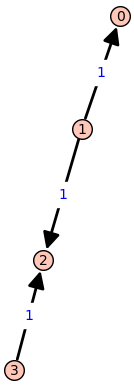

In [136]:
M=graphMagma([('K',2),('N',2),('K',2)], value_number=2)
GM=GraphMagmaAlg(QQ,M)
R = GM.magma_algebra
GM.quiver.show(edge_labels=True)


In [132]:
GM.build_relations()

[
[0 1 0 0 0 0 0]  [0 0 1 0 0 0 0]  [0 0 0 1 0 0 0]  [0 0 0 0 1 0 0]
[0 1 0 0 0 0 0]  [0 1 0 0 0 0 0]  [0 1 0 0 0 0 0]  [0 1 0 0 0 0 0]
[0 0 1 0 0 0 0]  [0 0 1 0 0 0 0]  [0 0 1 0 0 0 0]  [0 0 1 0 0 0 0]
[0 1 0 0 0 0 0]  [0 0 1 0 0 0 0]  [0 0 0 1 0 0 0]  [0 0 0 0 1 0 0]
[0 1 0 0 0 0 0]  [0 0 1 0 0 0 0]  [0 0 0 1 0 0 0]  [0 0 0 0 1 0 0]
[0 1 0 0 0 0 0]  [0 0 1 0 0 0 0]  [0 0 0 1 0 0 0]  [0 0 0 0 1 0 0]
[0 1 0 0 0 0 0], [0 0 1 0 0 0 0], [0 0 0 1 0 0 0], [0 0 0 0 1 0 0],

[0 0 0 0 0 1 0]  [0 0 0 0 0 0 1]
[0 1 0 0 0 0 0]  [0 1 0 0 0 0 0]
[0 0 1 0 0 0 0]  [0 0 1 0 0 0 0]
[0 0 0 1 0 0 0]  [0 0 0 1 0 0 0]
[0 0 0 0 1 0 0]  [0 0 0 0 1 0 0]
[0 0 0 0 0 1 0]  [0 0 0 0 0 1 0]
[0 0 0 0 0 0 1], [0 0 0 0 0 0 1]
]

In [137]:
GM.getMultiplicationTable()

Multiplication table of the algebra on the module:

      | a_0_0 a_0_1 a_1_0 a_1_1 a_2_0 a_2_1 
------- ----- ----- ----- ----- ----- ----- 
a_0_0 | a_0_0 a_0_0 a_0_0 a_0_0 a_0_0 a_0_0 
a_0_1 | a_0_1 a_0_1 a_0_1 a_0_1 a_0_1 a_0_1 
a_1_0 | a_0_0 a_0_1 a_1_0 a_1_1 a_1_0 a_1_0 
a_1_1 | a_0_0 a_0_1 a_1_0 a_1_1 a_1_1 a_1_1 
a_2_0 | a_0_0 a_0_1 a_1_0 a_1_1 a_2_0 a_2_0 
a_2_1 | a_0_0 a_0_1 a_1_0 a_1_1 a_2_1 a_2_1 


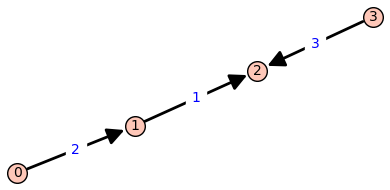

In [9]:
M2=graphMagma([('N',3),('N',2),('K',4)])
GM2=GraphMagmaAlg(QQ,M2)
GM2.quiver.show(edge_labels=True)

In [10]:
GM.getDecomposition()

[a_0_0, -a_0_0 + a_1_0, -a_1_0 + a_2_0, 1 - a_2_0]

In [11]:
P1=GM.Indecomposable_Projective(1);P1

[-a_0_0 + a_1_0, -a_0_0 + a_0_1, a_1_0 - a_1_1]


GraphMagmaModule over Free algebra quotient on 6 generators ('a_0_0', 'a_0_1', 'a_1_0', 'a_1_1', 'a_2_0', 'a_2_1') and dimension 7 over Rational Field with dimension 3
Basis: [(1, 0, 0), (0, 1, 0), (0, 0, 1)]

In [12]:
P1.vector_space.basis()

[
(1, 0, 0),
(0, 1, 0),
(0, 0, 1)
]

In [13]:
GM.getMultiplicationTable()

Multiplication table of the algebra on the module:

      | a_0_0 a_0_1 a_1_0 a_1_1 a_2_0 a_2_1 
------- ----- ----- ----- ----- ----- ----- 
a_0_0 | a_0_0 a_0_0 a_0_0 a_0_0 a_0_0 a_0_0 
a_0_1 | a_0_1 a_0_1 a_0_1 a_0_1 a_0_1 a_0_1 
a_1_0 | a_0_0 a_0_1 a_1_0 a_1_1 a_1_0 a_1_0 
a_1_1 | a_0_0 a_0_1 a_1_0 a_1_1 a_1_1 a_1_1 
a_2_0 | a_0_0 a_0_1 a_1_0 a_1_1 a_2_0 a_2_0 
a_2_1 | a_0_0 a_0_1 a_1_0 a_1_1 a_2_1 a_2_1 


In [14]:
GM.simple_left_ideals

[[-a_0_0 + a_0_1],
 [-a_0_0 + a_1_0],
 [-a_1_0 + a_1_1, a_2_0 - a_2_1],
 [1 - a_2_0]]

In [15]:
GM.simple_right_ideals

[[a_0_0], [-a_0_0 + a_0_1, a_1_0 - a_1_1], [-a_1_0 + a_2_0], [-a_2_0 + a_2_1]]

## Define a module structure on GM

In [16]:
GM.getLocalProjectiveBasis(0)

[a_0_0]

In [17]:
# The indecomposable projective right module of index 2
P2 = GM.Indecomposable_Projective(2)
P2.getMultiplicationTable()

[-a_1_0 + a_2_0]
Scalar multiplication table on the module with basis v0:

      |        v0 
-------   ------- 
a_0_0 |         0 
a_0_1 |         0 
a_1_0 |         0 
a_1_1 |         0 
a_2_0 |        v0 
a_2_1 |        v0 


In [18]:
# The indecomposable injective left module of index 1
I1=P1.dualize();I1.getMultiplicationTable()

Scalar multiplication table on the module with basis v0,v1,v2:

      |        v0        v1        v2 
-------   -------   -------   ------- 
a_0_0 |         0        v1         0 
a_0_1 |         0     v0+v1         0 
a_1_0 |        v0        v1         0 
a_1_1 |        v0        v1       -v0 
a_2_0 |        v0        v1        v2 
a_2_1 |        v0        v1        v2 


In [19]:
# Define a submodule of the indecomposable injective left module I(1)
N=I1.submodule([I1.vector_space([0,-5,0])])
N.getMultiplicationTable()

Scalar multiplication table on the module with basis v0,v1:

      |        v0        v1 
-------   -------   ------- 
a_0_0 |         0        v1 
a_0_1 |         0     v0+v1 
a_1_0 |        v0        v1 
a_1_1 |        v0        v1 
a_2_0 |        v0        v1 
a_2_1 |        v0        v1 


In [20]:
# Query the endomorphism ring of N
N.Endomorphism_Ring();

The endomorphism ring of the module is isomorphic to a subalgebra of the algebra of matrices of size  2 x 2  consisting of the matrices of the form:



<IPython.core.display.Math object>

where  (r1,)  is/are element(s) of the Rational Field. 
 



In [21]:
# Check if N is indecomposable
N.is_Indecomposable()

True

In [22]:
I12=I1.direct_sum(I1)

In [23]:
I12.getMultiplicationTable()

Scalar multiplication table on the module with basis v0,v1,v2,v3,v4,v5:

      |        v0        v1        v2        v3        v4        v5 
-------   -------   -------   -------   -------   -------   ------- 
a_0_0 |         0         0        v2         0        v4         0 
a_0_1 |         0         0     v0+v2         0     v1+v4         0 
a_1_0 |        v0        v1        v2         0        v4         0 
a_1_1 |        v0        v1        v2       -v0        v4       -v1 
a_2_0 |        v0        v1        v2        v3        v4        v5 
a_2_1 |        v0        v1        v2        v3        v4        v5 


In [24]:
K=I12.submodule([I12.vector_space([1,-1,1,1,1,1]),I12.vector_space([0,0,0,0,0,0])])
K.is_Indecomposable(reason=True)

The module is decomposable since there are more than two idempotent elements of the endomorphism ring of the form:




<IPython.core.display.Math object>



for which  [
[r3 == 0, r4 == r6, r5 == r6 - 1],
[r3 == 1, r4 == r7, r5 == r7],
[r3 == 0, r4 == 1, r5 == 0],
[r3 == 0, r4 == 0, r5 == 0],
[r3 == 1, r4 == 0, r5 == 0],
[r3 == 1, r4 == 1, r5 == 0],
[r3 == 0, r4 == 0, r5 == -1],
[r3 == 1, r4 == 1, r5 == 1]
] .
 



(
[     r4 r3 - r4       0       0]      
[     r5 r3 - r5       0       0]      
[      0       0      r3       0]      
[      0       0       0      r3], None
)

In [25]:
K.getMultiplicationTable()

Scalar multiplication table on the module with basis v0,v1,v2,v3:

      |         v0         v1         v2         v3 
-------   --------   --------   --------   -------- 
a_0_0 |          0          0         v2          0 
a_0_1 |          0          0   v0+v1+v2          0 
a_1_0 |         v0         v1         v2          0 
a_1_1 |         v0         v1         v2     -v0-v1 
a_2_0 |         v0         v1         v2         v3 
a_2_1 |         v0         v1         v2         v3 


# Classifications of Indecomposable Injective Left Modules I(i)

## 1<i<n

### KK: The case when (u_i,u_{i+1})=(K_p,K_q)

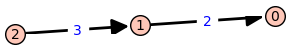

In [26]:
GMA_KK=GraphMagmaAlg(QQ,graphMagma([('K',3),('K',4)]))
R_KK=GMA_KK.magma_algebra
GMA_KK.quiver.show(edge_labels=True,figsize=(3,3))

In [27]:
P1_KK=GMA_KK.Indecomposable_Projective(1)
I1_KK=P1_KK.dualize()
I1_KK.getMultiplicationTable()

[-a_0_0 + a_1_0, -a_0_0 + a_0_1, -a_0_0 + a_0_2]
Scalar multiplication table on the module with basis v0,v1,v2:

      |        v0        v1        v2 
-------   -------   -------   ------- 
a_0_0 |         0        v1        v2 
a_0_1 |         0     v0+v1        v2 
a_0_2 |         0        v1     v0+v2 
a_1_0 |        v0        v1        v2 
a_1_1 |        v0        v1        v2 
a_1_2 |        v0        v1        v2 
a_1_3 |        v0        v1        v2 


In [28]:
P1_KK.getMultiplicationTable()

Scalar multiplication table on the module with basis v0,v1,v2:

      |        v0        v1        v2 
-------   -------   -------   ------- 
a_0_0 |        v0        v1         0 
a_0_1 |        v0        v1        v0 
a_0_2 |        v0        v1        v1 
a_1_0 |        v0        v1        v2 
a_1_1 |        v0        v1        v2 
a_1_2 |        v0        v1        v2 
a_1_3 |        v0        v1        v2 


#### A Case Study

In [29]:
D=I1_KK.direct_sum(I1_KK)
# D has a basis {v0,v1,v2,v3,v4,v5} and soc(D)=span{v0,v3}
D.getMultiplicationTable()

Scalar multiplication table on the module with basis v0,v1,v2,v3,v4,v5:

      |        v0        v1        v2        v3        v4        v5 
-------   -------   -------   -------   -------   -------   ------- 
a_0_0 |         0         0        v2        v3        v4        v5 
a_0_1 |         0         0     v0+v2        v3     v1+v4        v5 
a_0_2 |         0         0        v2     v0+v3        v4     v1+v5 
a_1_0 |        v0        v1        v2        v3        v4        v5 
a_1_1 |        v0        v1        v2        v3        v4        v5 
a_1_2 |        v0        v1        v2        v3        v4        v5 
a_1_3 |        v0        v1        v2        v3        v4        v5 


In [30]:
# We define a submodule of D, containing the soc(D), spanned by the vectors 
# v0,v3,\apha_1*v1+\alpha_2*v2+\alpha_3*v4+\alpha_4*v5,
# where \alpha_i are the coefficients of the linear combination
E=D.submodule([D.vector_space([1,0,0,0,0,0]),D.vector_space([0,0,0,1,0,0]),D.vector_space([0,1,2,0,-1,1])])
E.getMultiplicationTable()
E.is_Indecomposable(reason=True)
# The result is True, which means that the submodule is indecomposable. This leads to the conjecture that E is indecomposable
# if and only if the determinant of the matrix([\alpha_1,\alpha_2],[\alpha_3,\alpha_4]) is non-zero.

Scalar multiplication table on the module with basis v0,v1,v2,v3:

      |             v0             v1             v2             v3 
-------   ------------   ------------   ------------   ------------ 
a_0_0 |              0              0             v2             v3 
a_0_1 |              0              0   v0-1/2*v1+v2             v3 
a_0_2 |              0              0      1/2*v1+v2          v0+v3 
a_1_0 |             v0             v1             v2             v3 
a_1_1 |             v0             v1             v2             v3 
a_1_2 |             v0             v1             v2             v3 
a_1_3 |             v0             v1             v2             v3 
The module is decomposable since there are more than two idempotent elements of the endomorphism ring of the form:




<IPython.core.display.Math object>



for which  [
[r8 == 1, r9 == 0],
[r8 == 0, r9 == 0],
[r8 == 0, r9 == 1],
[r8 == 1, r9 == 1]
] .
 



(
[          r9 -2*r8 + 2*r9            0            0]      
[           0           r8            0            0]      
[           0            0           r8            0]      
[           0            0     -r8 + r9           r9], None
)

In [31]:
# A 4-dimesional indecomposable submodule of D
E1=D.submodule([D.vector_space([1,0,0,0,0,0]),D.vector_space([0,0,0,1,0,0]),
                D.vector_space([0,2,-1,0,1,0]),D.vector_space([0,1,0,0,0,1])])
E1.is_Indecomposable(reason=True)
E1.getMultiplicationTable()

The module is decomposable since there are more than two idempotent elements of the endomorphism ring of the form:




<IPython.core.display.Math object>



for which  [
[r10 == r13, r11 == r13, r12 == -r13 + 1],
[r10 == r14, r11 == r14 - 1, r12 == -r14 + 1],
[r10 == 0, r11 == 0, r12 == 0],
[r10 == 1, r11 == 0, r12 == 1],
[r10 == 0, r11 == 0, r12 == 1],
[r10 == 1, r11 == 0, r12 == 0],
[r10 == 1, r11 == 1, r12 == 0],
[r10 == 0, r11 == -1, r12 == 1]
] .
 

Scalar multiplication table on the module with basis v0,v1,v2,v3,v4:

      |         v0         v1         v2         v3         v4 
-------   --------   --------   --------   --------   -------- 
a_0_0 |          0          0         v2         v3         v4 
a_0_1 |          0          0   v0-v1+v2         v3         v4 
a_0_2 |          0          0         v2      v0+v3      v1+v4 
a_1_0 |         v0         v1         v2         v3         v4 
a_1_1 |         v0         v1         v2         v3         v4 
a_1_2 |         v0         v1         v2         v3         v4 
a_1_3 |         v0         v1         v2         v3         v4 


In [32]:
# A 4-dimesional decomposable submodule of D
E2=D.submodule([D.vector_space([1,0,0,0,0,0]),D.vector_space([0,0,0,1,0,0]),
                D.vector_space([0,-3,-1,0,1,0]),D.vector_space([0,1,0,0,0,1])])
E2.is_Indecomposable(reason=True)
E2.getMultiplicationTable()

The module is decomposable since there are more than two idempotent elements of the endomorphism ring of the form:




<IPython.core.display.Math object>



for which  [
[r15 == r18, r16 == r18, r17 == -r18 + 1],
[r15 == r19, r16 == r19 - 1, r17 == -r19 + 1],
[r15 == 0, r16 == 0, r17 == 0],
[r15 == 1, r16 == 0, r17 == 1],
[r15 == 0, r16 == 0, r17 == 1],
[r15 == 1, r16 == 0, r17 == 0],
[r15 == 1, r16 == 1, r17 == 0],
[r15 == 0, r16 == -1, r17 == 1]
] .
 

Scalar multiplication table on the module with basis v0,v1,v2,v3,v4:

      |         v0         v1         v2         v3         v4 
-------   --------   --------   --------   --------   -------- 
a_0_0 |          0          0         v2         v3         v4 
a_0_1 |          0          0   v0-v1+v2         v3         v4 
a_0_2 |          0          0         v2      v0+v3      v1+v4 
a_1_0 |         v0         v1         v2         v3         v4 
a_1_1 |         v0         v1         v2         v3         v4 
a_1_2 |         v0         v1         v2         v3         v4 
a_1_3 |         v0         v1         v2         v3         v4 


### KN: The case when (u_i,u_{i+1})=(K_p,N_q)

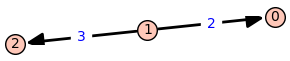

In [33]:
GMA_KN=GraphMagmaAlg(QQ,graphMagma([('K',3),('N',4)]))
R_KN=GMA_KN.magma_algebra
GMA_KN.quiver.show(edge_labels=True,figsize=(3,3))

In [34]:
P1_KN=GMA_KN.Indecomposable_Projective(1)
I1_KN=P1_KN.dualize()
I1_KN.getMultiplicationTable()

[-a_0_0 + a_1_0, -a_0_0 + a_0_1, -a_0_0 + a_0_2, a_1_0 - a_1_1, a_1_0 - a_1_2, a_1_0 - a_1_3]
Scalar multiplication table on the module with basis v0,v1,v2,v3,v4,v5:

      |        v0        v1        v2        v3        v4        v5 
-------   -------   -------   -------   -------   -------   ------- 
a_0_0 |         0        v1        v2         0         0         0 
a_0_1 |         0     v0+v1        v2         0         0         0 
a_0_2 |         0        v1     v0+v2         0         0         0 
a_1_0 |        v0        v1        v2         0         0         0 
a_1_1 |        v0        v1        v2       -v0         0         0 
a_1_2 |        v0        v1        v2         0       -v0         0 
a_1_3 |        v0        v1        v2         0         0       -v0 


### NK: The case when (u_i,u_{i+1})=(N_p,K_q)

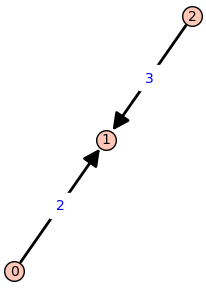

In [35]:
GMA_NK=GraphMagmaAlg(QQ,graphMagma([('N',3),('K',4)]))
R_NK=GMA_NK.magma_algebra
GMA_NK.quiver.show(edge_labels=True,figsize=(3,3))

In [36]:
P1_NK=GMA_NK.Indecomposable_Projective(1)
I1_NK=P1_NK.dualize()
I1_NK.getMultiplicationTable()

[-a_0_0 + a_1_0]
Scalar multiplication table on the module with basis v0:

      |        v0 
-------   ------- 
a_0_0 |         0 
a_0_1 |         0 
a_0_2 |         0 
a_1_0 |        v0 
a_1_1 |        v0 
a_1_2 |        v0 
a_1_3 |        v0 


### NN: The case when (u_i,u_{i+1})=(N_p,N_q)

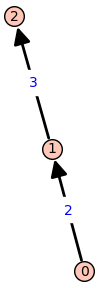

In [37]:
GMA_NN=GraphMagmaAlg(QQ,graphMagma([('N',3),('N',4)]))
R_NN=GMA_NN.magma_algebra
GMA_NN.quiver.show(edge_labels=True,figsize=(3,3))

In [38]:
P1_NN=GMA_NN.Indecomposable_Projective(1)
I1_NN=P1_NN.dualize()
I1_NN.getMultiplicationTable()

[-a_0_0 + a_1_0, a_1_0 - a_1_1, a_1_0 - a_1_2, a_1_0 - a_1_3]
Scalar multiplication table on the module with basis v0,v1,v2,v3:

      |        v0        v1        v2        v3 
-------   -------   -------   -------   ------- 
a_0_0 |         0         0         0         0 
a_0_1 |         0         0         0         0 
a_0_2 |         0         0         0         0 
a_1_0 |        v0         0         0         0 
a_1_1 |        v0       -v0         0         0 
a_1_2 |        v0         0       -v0         0 
a_1_3 |        v0         0         0       -v0 


## Parametric Search for Indecomposable Modules

In [39]:
a,b,c,d,e,f=SR.var('a b c d e f')
# Define the rational function field
R.<a, b, c, d, e, f> = QQ['a, b, c, d, e, f']
F = R.fraction_field()
# Define the 2-value graph magma algebra induced by the graph K3xK4
GMAsr=GraphMagmaAlg(F,graphMagma([('K',3),('K',4)]))
strg=f"+".join([f'R*({e})' for e in GMAsr.getDecomposition()])
print('The local projective left decomposition of the graph magma algbera R is',strg)
print(f'The indecomposable projective right module of index 1 is R*({GMAsr.getDecomposition()[1]})')
# Define the indecomposable projective right module of index 1
P2=GMAsr.Indecomposable_Projective(1)
P3=GMAsr.Indecomposable_Projective(2)
# Define the indecomposable injective left module of index 1
I2=P2.dualize()
I3=P3.dualize()
print(f'The indecomposable injective left module of index 1 is the dual of R*({GMAsr.getDecomposition()[1]})')
# Define E=IxI
E=I2.direct_sum(I2)
print('Let E = I_2  X  I_2. Then the')
E.getMultiplicationTable()

The local projective left decomposition of the graph magma algbera R is R*(a_0_0)+R*(-a_0_0 + a_1_0)+R*(1 - a_1_0)
The indecomposable projective right module of index 1 is R*(-a_0_0 + a_1_0)
[-a_0_0 + a_1_0, -a_0_0 + a_0_1, -a_0_0 + a_0_2]
[1 - a_1_0, -a_1_0 + a_1_1, -a_1_0 + a_1_2, -a_1_0 + a_1_3]
The indecomposable injective left module of index 1 is the dual of R*(-a_0_0 + a_1_0)
Let E = I_2  X  I_2. Then the
Scalar multiplication table on the module with basis v0,v1,v2,v3,v4,v5:

      |        v0        v1        v2        v3        v4        v5 
-------   -------   -------   -------   -------   -------   ------- 
a_0_0 |         0         0        v2        v3        v4        v5 
a_0_1 |         0         0     v0+v2        v3     v1+v4        v5 
a_0_2 |         0         0        v2     v0+v3        v4     v1+v5 
a_1_0 |        v0        v1        v2        v3        v4        v5 
a_1_1 |        v0        v1        v2        v3        v4        v5 
a_1_2 |        v0        v1 

In [40]:
soc_E=E.get_socle();soc_E

The socle of the module is spanned by: 

<IPython.core.display.Math object>

[(1, 0, 0, 0, 0, 0), (0, 1, 0, 0, 0, 0)]

### Nonzero Proper Submodules of I_2

In [41]:
# 1-dimensional indecomposable
A1=I2.submodule([I2.vector_space([1,0,0])]) #  simple (and hence indecomposable)
# 2-dimensional indecomposable
A2_1=I2.submodule([I2.vector_space([0,1,a])]) # indecomposable
A2_2=I2.submodule([I2.vector_space([0,0,1])]) # indecomposable

### Essential Proper Submodules of E

In [42]:
# 3-dimensional essential submodules of E
A3_1=E.submodule(soc_E+[E.vector_space([0,0,1,a,b,c])]) # indecomposable
A3_1a=E.submodule(soc_E+[E.vector_space([0,0,1,a,b,a*b])]) # decomposable
A3_1b=E.submodule(soc_E+[E.vector_space([0,0,1,a,0,0])]) # decomposable and isomorphic to A3_1a
A3_2=E.submodule(soc_E+[E.vector_space([0,0,0,1,d,e])]) # indecomposable
A3_3=E.submodule(soc_E+[E.vector_space([0,0,0,0,1,f])]) # decomposable
A3_4=E.submodule(soc_E+[E.vector_space([0,0,0,0,0,1])]) # decomposable
# 4-dimensional essential submodules of E
A4_1=E.submodule(soc_E+[E.vector_space([0,0,1,0,a,b]),E.vector_space([0,0,0,1,c,d])]) # decomposable
A4_2=E.submodule(soc_E+[E.vector_space([0,0,1,0,a,1/2*(a-d)]),E.vector_space([0,0,0,1,-1/2*(a-d),d])]) # indecomposable
# 5-dimensional essential submodules of E
A5=E.submodule(soc_E+[E.vector_space([0,0,1,0,a,b]),E.vector_space([0,0,0,1,0,c]),E.vector_space([0,0,0,0,1,d])]) # indecomposable
A2_2=A4_1.submodule([A4_1.vector_space([0,0,1,1])]) # indecomposable

In [43]:
display(Math(latex(list(A3_1.scalar_mults.values()))))

<IPython.core.display.Math object>

In [44]:
display(Math(latex(list(A4_1.scalar_mults.values()))))

<IPython.core.display.Math object>

In [45]:
T=Matrix(F,[[1,a,0,0,-1,0,0,0],[0,c,0,0,0,-1,0,0],[0,0,1,a,-a,0,-c,0],[0,0,0,c,0,-a,0,-c]])
U=T.echelon_form()
T.right_kernel().basis()

[
(1, 0, 0, 0, 1, 0, (-a)/c, 0),
(0, 1, 0, 0, a, c, (-a^2)/c, -a),
(0, 0, 1, 0, 0, 0, 1/c, 0),
(0, 0, 0, 1, 0, 0, a/c, 1)
]

In [46]:
A4_1.getEndoBasis()

[
[1 0 0 0]  [        0         1         0         0]
[0 1 0 0]  [b*c - a*d     a + d         0         0]
[0 0 1 0]  [        0         0         a         c]
[0 0 0 1], [        0         0         b         d]
]

In [47]:
print(A3_1b.getProjectionRelations())
display(Math(latex(A3_1b.getEndoBasis())))

['t0==t0^2', 't1==t0*t1 + t1*t2', 't2==t2^2']


<IPython.core.display.Math object>

In [48]:
display(Math(latex(GMM_Morph(A2_1,A3_1a).splitting_morphisms(inverses=True))))
display(Math(latex(GMM_Morph(A3_1a,A3_1b).isomorphisms)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [49]:
A3_2.is_Indecomposable(),A3_3.is_Indecomposable(),A3_4.is_Indecomposable()

(True, False, False)

In [50]:
print(A3_3.getProjectionRelations())
display(Math(latex(A3_3.getEndoBasis())))
T=A3_3.submodule([A3_3.vector_space([1,1,0])]);GMM_Morph(T,A3_3).splitting_morphisms(inverses=True)

['t0==t0^2', 't1==t0*t1 + t1*t2', 't2==t2^2']


<IPython.core.display.Math object>

[[
[1/z0]            
[ r40]            
[   0], [z0  0  0]
]]

In [51]:
A4_1.is_Indecomposable(reason=True)

The module is decomposable since there are more than two idempotent elements of the endomorphism ring of the form:




<IPython.core.display.Math object>



for which  [
[r41 == 1, r42 == 0],
[r41 == 0, r42 == 0],
[r41 == 1/2*(a^2 + 4*b*c - 2*a*d + d^2 + sqrt(a^2 + 4*b*c - 2*a*d + d^2)*(a - d))/(a^2 + 4*b*c - 2*a*d + d^2), r42 == -1/sqrt(a^2 + 4*b*c - 2*a*d + d^2)],
[r41 == 1/2*(a^2 + 4*b*c - 2*a*d + d^2 - sqrt(a^2 + 4*b*c - 2*a*d + d^2)*(a - d))/(a^2 + 4*b*c - 2*a*d + d^2), r42 == 1/sqrt(a^2 + 4*b*c - 2*a*d + d^2)]
] .
 



(
[       -d*r42 + r41                 r42                   0                   0]
[  b*c*r42 - a*d*r42         a*r42 + r41                   0                   0]
[                  0                   0 a*r42 - d*r42 + r41               c*r42]
[                  0                   0               b*r42                 r41],

None
)

In [52]:
A4_1.Endomorphism_Ring(symbolic=True)

The endomorphism ring of the module is isomorphic to a subalgebra of the algebra of matrices of size  4 x 4  consisting of the matrices of the form:



<IPython.core.display.Math object>

where  (a, b, c, d, r43, r44)  is/are element(s) of the Fraction Field of Multivariate Polynomial Ring in a, b, c, d, e, f over Rational Field. 
 



[       -d*r44 + r43                 r44                   0                   0]
[  b*c*r44 - a*d*r44         a*r44 + r43                   0                   0]
[                  0                   0 a*r44 - d*r44 + r43               c*r44]
[                  0                   0               b*r44                 r43]

In [53]:
# Create the polynomial ring with one variable
u= SR.var('u')
P = PolynomialRing(F, u)
# Define the ideal generated by the relation
ideal = P.ideal(u^2 - F((a-d)^2+4*b*c))
# Create the quotient ring
S=P.quotient(ideal)
# Define the graph magma algebra over the quotient ring
F2=S.fraction_field();ubar= F2(S.gen())
GMAsr2=GraphMagmaAlg(F2,graphMagma([('K',3),('K',4)]))
I2_2=GMAsr2.Indecomposable_Projective(1).dualize()
E2_2=I2_2.direct_sum(I2_2)
A2_41=E2_2.submodule([E2_2.vector_space([0,0,1,0,a,b]),E2_2.vector_space([0,0,0,1,c,d])])
A2_2=I2_2.submodule([I2_2.vector_space([0,1,1/2*(d-a+ubar)/c])])
#GMM_Morph(A2_2,A2_41).morphisms
A2_2.getMultiplicationTable()

[-a_0_0 + a_1_0, -a_0_0 + a_0_1, -a_0_0 + a_0_2]
Scalar multiplication table on the module with basis v0,v1:

      |                                        v0                                        v1 
-------   ---------------------------------------   --------------------------------------- 
a_0_0 |                                         0                                        v1 
a_0_1 |                                         0                                     v0+v1 
a_0_2 |                                         0   (1/2/c*ubar + (-1/2*a + 1/2*d)/c)*v0+v1 
a_1_0 |                                        v0                                        v1 
a_1_1 |                                        v0                                        v1 
a_1_2 |                                        v0                                        v1 
a_1_3 |                                        v0                                        v1 


In [54]:
string=str(A4_1.projections()[2].list()).replace('sqrt(a^2 + 4*b*c - 2*a*d + d^2)','ubar').replace('[','').replace(']','')
entries=string.split(',') # This is a hack to get the string representation of the projection
# Convert entries into a list of elements of F2
F2_elements = [F2(e) for e in entries]		
M=Matrix(F2,4,4,F2_elements)
generators1=[A2_41.vector_space(list(b)) for b in M.column_space().basis()]
generators2=[A2_41.vector_space(list(b)) for b in M.right_kernel().basis()]
A=A2_41.submodule(generators1) # A is a 2-dimensional indecomposable submodule of A2_41
B=A2_41.submodule(generators2) # B is a 2-dimensional indecomposable submodule of A2_41
display(Math(latex(M)))
#M.row_space().basis(),M.left_kernel().basis() # The basis of the row space of M
direct_sum=A.direct_sum(B)
list(direct_sum.scalar_mults.values()) # The scalar multiplication matrices of the direct sum

<IPython.core.display.Math object>

[
[0 0 0 0]  [0 0 1 0]  [                                             0                                              0 (1/8/(-1/4*c))*ubar + (-1/4*a + 1/4*d)/(1/2*c)                                              0]
[0 0 0 0]  [0 0 0 1]  [                                             0                                              0                                              0        ((-2)/(-4*c))*ubar + (2*a - 2*d)/(-4*c)]
[0 0 1 0]  [0 0 1 0]  [                                             0                                              0                                              1                                              0]
[0 0 0 1], [0 0 0 1], [                                             0                                              0                                              0                                              1],

[1 0 0 0]  [1 0 0 0]  [1 0 0 0]  [1 0 0 0]
[0 1 0 0]  [0 1 0 0]  [0 1 0 0]  [0 1 0 0]
[0 0 1 0]  [0 0 1 0]  [0 0 1 0]  [0 0 1 0]
[0 0 0 1], [0 0 0 1

In [55]:
A3_41=E.submodule(soc_E+[E.vector_space([0,0,1,0,a,a]),E.vector_space([0,0,0,1,c,c])])#;A3_41.is_Indecomposable(reason=True);Proj2=A3_41.projections()
B31=[A3_41.vector_space(list(b)) for b in Proj2[-1].canonicalize_radical().column_space().basis()]
B32=[A3_41.vector_space(list(b)) for b in Proj2[-1].canonicalize_radical().right_kernel().basis()]

NameError: name 'Proj2' is not defined

In [ ]:
latex_string=r'A^{(iii)}_{41}='+r'\langle'+latex(', '.join(str(x) for x in B31))+r'\rangle\oplus\langle'+latex(', '.join(str(x) for x in B32))+ r'\rangle'
display(Math(latex_string))

<IPython.core.display.Math object>

In [ ]:
A3=A3_41.submodule(B31);B3=A3_41.submodule(B32)
GMM_Morph(A3,A3_41).splitting_morphisms()[0].column_space().basis() # The morphisms between A3 and B3

[
(1, a + c, 0, 0),
(0, 0, 1, 1)
]

In [ ]:
ubar/(a^2 + 4*b*c - 2*a*d + d^2)==1/ubar


True

In [ ]:
display(Math(latex(generators1))),display(Math(latex(generators2)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

(None, None)

In [ ]:
P4_1=A4_1.projections(printable=True)

Projections of the module are idempotent elements of its endomorphism ring.
They are of the form:





<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [ ]:
Mtrs=[A4_1.scalar_mults[str(g)] for g in A4_1.algebra.gens()]
stacked=block_matrix([[M.tensor_product(identity_matrix(A4_1.algebra.base_ring(),A4_1.dimension))-identity_matrix(A4_1.algebra.base_ring(),A4_1.dimension).tensor_product(M.transpose())] for M in Mtrs])
B=stacked.right_kernel().basis() # The basis of the right kernel of the stacked matrix
End=[Matrix(A4_1.algebra.base_ring(),A4_1.dimension,list(b)) for b in B] # The endomorphisms of the indecomposable module A4_1
l,m=var('l m')
P=l*identity_matrix(A4_1.algebra.base_ring(),A4_1.dimension)+m*End[1]
solution=solve((P^2-P).list(),[l,m],dict=True)
#Matrix(A4_1.algebra.base_ring(),A4_1.dimension,A4_1.dimension,[s.rhs() for s in solution[2]])
P.substitute(solution[2]).canonicalize_radical() # The idempotent endomorphism of the indecomposable module A4_1

[1/2*(a^2 + 4*b*c - 2*a*d + d^2 - sqrt(a^2 + 4*b*c - 2*a*d + d^2)*(a + d))/(a^2 + 4*b*c - 2*a*d + d^2)                                                                     1/sqrt(a^2 + 4*b*c - 2*a*d + d^2)                                                                                                     0                                                                                                     0]
[                                                          (b*c - a*d)/sqrt(a^2 + 4*b*c - 2*a*d + d^2)                         1/2*(a + d + sqrt(a^2 + 4*b*c - 2*a*d + d^2))/sqrt(a^2 + 4*b*c - 2*a*d + d^2)                                                                                                     0                                                                                                     0]
[                                                                                                    0                                                                              

In [ ]:
Mtrs=[A2_41.scalar_mults[str(g)] for g in A2_41.algebra.gens()]
stacked=block_matrix([[M.tensor_product(identity_matrix(A2_41.algebra.base_ring(),A2_41.dimension))-identity_matrix(A2_41.algebra.base_ring(),A2_41.dimension).tensor_product(M.transpose())] for M in Mtrs])
B=stacked.right_kernel().basis() # The basis of the right kernel of the stacked matrix
End=[Matrix(A2_41.algebra.base_ring(),A2_41.dimension,list(b)) for b in B] # The endomorphisms of the indecomposable module A2_41
End# The endomorphism of the indecomposable module A2_41 raised to the power of 4
#[[E*M==M*E for M in Mtrs] for E in End] # Check if the endomorphisms commute with the scalar multiplication matrices

[
[1 0 0 0]  [        0         1         0         0]
[0 1 0 0]  [b*c - a*d     a + d         0         0]
[0 0 1 0]  [        0         0         a         c]
[0 0 0 1], [        0         0         b         d]
]

In [ ]:
basis_vectors = [vector(F2, m.list()) for m in End]
v=vector(F2,(End[1]^4).list())
V = VectorSpace(F2, 16)
W = V.span(basis_vectors)
if v in W:
	print(W.coordinate_vector(v))


(a^2*b*c + b^2*c^2 - a^3*d - a^2*d^2 + b*c*d^2 - a*d^3, a^3 + 2*a*b*c + a^2*d + 2*b*c*d + a*d^2 + d^3)


In [ ]:
End[1]^4

[                                                    a^2*b*c + b^2*c^2 - a^3*d - a^2*d^2 + b*c*d^2 - a*d^3                                                             a^3 + 2*a*b*c + a^2*d + 2*b*c*d + a*d^2 + d^3                                                                                                         0                                                                                                         0]
[a^3*b*c + 2*a*b^2*c^2 - a^4*d - a^2*b*c*d + 2*b^2*c^2*d - a^3*d^2 - a*b*c*d^2 - a^2*d^3 + b*c*d^3 - a*d^4                         a^4 + 3*a^2*b*c + b^2*c^2 + a^3*d + 4*a*b*c*d + a^2*d^2 + 3*b*c*d^2 + a*d^3 + d^4                                                                                                         0                                                                                                         0]
[                                                                                                        0                                          

In [ ]:
x, y = polygen(F2, 'x, y')  # Define symbolic variables x and y
X = diagonal_matrix(A2_41.dimension*[x]) + diagonal_matrix(A2_41.dimension*[y])* End[1]
p=(X^2 - X);p

[                                                 x^2 + (b*c - a*d)*y^2 - x                                                    2*x*y + (a + d)*y^2 - y                                                                          0                                                                          0]
[(2*b*c - 2*a*d)*x*y + (a*b*c - a^2*d + b*c*d - a*d^2)*y^2 + (-b*c + a*d)*y       x^2 + (2*a + 2*d)*x*y + (a^2 + b*c + a*d + d^2)*y^2 - x + (-a - d)*y                                                                          0                                                                          0]
[                                                                         0                                                                          0                               x^2 + 2*a*x*y + (a^2 + b*c)*y^2 - x + (-a)*y                                         2*c*x*y + (a*c + c*d)*y^2 + (-c)*y]
[                                                                         0                   

In [ ]:
# İki boyutlu essential olmayan bir alt modül bulmak için devirli altmodülleri sorgulayabiliriz.
# Bu sorgulamadan üretecin t0=t1=0 olacak şekilde seçilmesi ve a+c=b+d olması koşulları elde edildi.
t0,t1,t2,t3,t4,t5=var('t0 t1 t2 t3 t4 t5')
R=F[t0,t1,t2,t3]
columns=[]
actions=A4_1.scalar_mults
T=Matrix(R,[[t0,t1,t2,t3]]).transpose()
for A in actions.values():
	A=Matrix(R,A)
	columns.append(A*T)
M=Matrix(R,columns)
N=M.change_ring(SR)
N

[          0           0          t2          t3]
[         t2 a*t2 + c*t3          t2          t3]
[         t3 b*t2 + d*t3          t2          t3]
[         t0          t1          t2          t3]
[         t0          t1          t2          t3]
[         t0          t1          t2          t3]
[         t0          t1          t2          t3]

In [ ]:
H = GMM_Morph(A2_2, A4_1)
H.representation

[
[0 0 0]  [       -(b + d)*y1 + y0                      y1                       0]
[0 0 0]  [         (b*c - a*d)*y1         (a - b)*y1 + y0                       0]
[0 0 0]  [                      0                       0 (a - b + c - d)*y1 + y0]
[0 0 0], [                      0                       0                      y0]
]

In [ ]:
H.embeddings[0].column_space()

Vector space of degree 4 and dimension 3 over Symbolic Ring
Basis matrix:
[                           1                            0                            0                            0]
[                           0                            1                            0                            0]
[                           0                            0                            1 y0/((a - b + c - d)*y1 + y0)]

In [ ]:
S=H.splitting_morphisms(inverses=True);S

[]

In [ ]:
latex_expression = r'\oplus'

# Concatenate the LaTeX strings
combined_latex = r'A_{41}' + latex(S[0][0].column_space().basis()) + latex_expression + latex(S[0][1].right_kernel().basis())
# Display the combined LaTeX expression
display(Math(LatexExpr(combined_latex)))

<IPython.core.display.Math object>

In [ ]:
H.representation[1].column_space()

Vector space of degree 3 and dimension 1 over Symbolic Ring
Basis matrix:
[    1 y1/y0     0]

## Essential Submodules of I^3

In [ ]:
# Define the graph magma algebra of the graph K3xK4
# Define the rational function field
a = SR.var('a', 5)  # Define 5 symbolic variables a0, a1, a2, a3, a4
b = SR.var('b', 4)  # Define 5 symbolic variables b0, b1, b2, b3
c= SR.var('c', 3)  # Define 5 symbolic variables c0, c1, c2
# Convert the symbolic variables to a list of strings
a_names = [str(ai) for ai in a] + [str(bi) for bi in b] + [str(ci) for ci in c]
# Define the polynomial ring
R = PolynomialRing(QQ, a_names)
a_names = R.gens()  # Define the generators of the polynomial ring
F = R.fraction_field()  # Define the fraction field
F = R.fraction_field()
# Define the 2-value graph magma algebra induced by the graph K3xK4
GMAsr3=GraphMagmaAlg(F,graphMagma([('K',3),('K',4)]))
# Define the indecomposable projective right module of index 1
P=GMAsr3.Indecomposable_Projective(1)
# Define the indecomposable injective left module of index 1
I=P.dualize()
# Define I^3
I3=I.direct_sum(I).direct_sum(I)
soc3=I3.get_socle(info=False)
# Define parameters
B4_0=I3.submodule(soc3+[I3.vector_space([0,0,0,1,a[0],a[1],a[2],a[3],a[4]])])
#Idemp=[]
#M,sol=B4_0.is_Indecomposable(get_info=True,symbolic=True)
# Substitute solutions in sol into the matrix M
Proj=B4_0.projections()
Proj

[
[                                                                                                                               -(a2*a3*r939 - a1*a4*r939)/(a0*a3 - a4)                                                                                                                                                                   r939                                                                                                                                   -(a0*a1*r939 - a2*r939)/(a0*a3 - a4)                                                                                                                                                                      0]  [                                                                                                     (a1*a4*r941 - (a2*r941 - a0)*a3 - a4)/(a0*a3 - a4)                                                                                                                                                    r941                       

In [ ]:
S1_4_0=B4_0.submodule([B4_0.vector_space([1,0,0,0])])
H14=GMM_Morph(S1_4_0,B4_0)
sp=H14.splitting_morphisms(inverses=True)
sp[0][1]

[-(a2*a3 - a1*a4)*z0/(a0*a3 - a4)                               z0    -(a0*a1 - a2)*z0/(a0*a3 - a4)                                0]

In [ ]:
latex_expression = r'\oplus'

# Concatenate the LaTeX strings
combined_latex = r'B_{40}=' + latex(sp[0][0].column_space().basis()) + latex_expression + latex(sp[0][1].right_kernel().basis())
# Display the combined LaTeX expression
display(Math(LatexExpr(combined_latex)))

<IPython.core.display.Math object>

In [ ]:
D=B4_0.submodule(sp[0][1].right_kernel().basis());D.is_Indecomposable(reason=True,symbolic=True)

The module is indecomposable since there are two idempotent elements of the endomorphism ring.


(
[r990    0    0]      
[   0 r990    0]      
[   0    0 r990], None
)

In [ ]:
D.getMultiplicationTable()

Scalar multiplication table on the module with basis v0,v1,v2:

      |               v0               v1               v2 
-------   --------------   --------------   -------------- 
a_0_0 |                0                0               v2 
a_0_1 |                0                0      v0+a1*v1+v2 
a_0_2 |                0                0   a0*v0+a2*v1+v2 
a_1_0 |               v0               v1               v2 
a_1_1 |               v0               v1               v2 
a_1_2 |               v0               v1               v2 
a_1_3 |               v0               v1               v2 


In [ ]:
GMM_Morph(D,A3_1).isomorphisms

[
[    (a1*y0 - a2)*y3/(a0 - y0)                            y3                             0]
[-(a2*y1 - a1*y2)*y3/(a0 - y0)     (a0*y1 - y2)*y3/(a0 - y0)                             0]
[                            0                             0     (a0*a1 - a2)*y3/(a0 - y0)]
]

In [ ]:
B5_0=I3.submodule(soc3+[I3.vector_space([0,0,0,1,0,a[0],a[1],a[2],a[3]]),I3.vector_space([0,0,0,0,1,b[0],b[1],b[2],b[3]])])
B5_0.is_Indecomposable(reason=True,symbolic=True)

The module is indecomposable since there are two idempotent elements of the endomorphism ring.


(
[r136    0    0    0    0]      
[   0 r136    0    0    0]      
[   0    0 r136    0    0]      
[   0    0    0 r136    0]      
[   0    0    0    0 r136], None
)

In [ ]:
B6_0=I3.submodule(soc3+[I3.vector_space([0,0,0,1,0,0,a[0],a[1],a[2]]),\
    I3.vector_space([0,0,0,0,1,0,b[0],b[1],b[2]]),\
        I3.vector_space([0,0,0,0,0,1,c[0],c[1],c[2]])])
M=B6_0.Endomorphism_Ring(symbolic=True)

The endomorphism ring of the module is isomorphic to a subalgebra of the algebra of matrices of size  6 x 6  consisting of the matrices of the form:



<IPython.core.display.Math object>

where  (a0, a1, a2, b0, b1, b2, c0, c1, c2, r143, r144, r145)  is/are element(s) of the Fraction Field of Multivariate Polynomial Ring in a0, a1, a2, a3, a4, b0, b1, b2, b3, c0, c1, c2 over Rational Field. 
 



In [ ]:
variables=list(filter(lambda v: v not in R.gens(),M.variables()))

In [ ]:
D6_0=B6_0.dualize()
D6_0.getMultiplicationTable()

Scalar multiplication table on the module with basis v0,v1,v2,v3,v4,v5:

      |                  v0                  v1                  v2                  v3                  v4                  v5 
-------   -----------------   -----------------   -----------------   -----------------   -----------------   ----------------- 
a_0_0 |                  v0                  v1                  v2                   0                   0                   0 
a_0_1 |                  v0                  v1                  v2                  v0                  v2   a1*v0+b1*v1+c1*v2 
a_0_2 |                  v0                  v1                  v2                  v1   a0*v0+b0*v1+c0*v2   a2*v0+b2*v1+c2*v2 
a_1_0 |                  v0                  v1                  v2                  v3                  v4                  v5 
a_1_1 |                  v0                  v1                  v2                  v3                  v4                  v5 
a_1_2 |                 

In [ ]:
B6_0.getMultiplicationTable()

Scalar multiplication table on the module with basis v0,v1,v2,v3,v4,v5:

      |                  v0                  v1                  v2                  v3                  v4                  v5 
-------   -----------------   -----------------   -----------------   -----------------   -----------------   ----------------- 
a_0_0 |                   0                   0                   0                  v3                  v4                  v5 
a_0_1 |                   0                   0                   0         v0+a1*v2+v3            b1*v2+v4         v1+c1*v2+v5 
a_0_2 |                   0                   0                   0      a0*v1+a2*v2+v3   v0+b0*v1+b2*v2+v4      c0*v1+c2*v2+v5 
a_1_0 |                  v0                  v1                  v2                  v3                  v4                  v5 
a_1_1 |                  v0                  v1                  v2                  v3                  v4                  v5 
a_1_2 |                 

In [ ]:
M.change_ring(PolynomialRing(F,variables))

[                                     r143 + (a0*c1^2 + a1*c2 - a2*c1 + b0*c1*c2 + b1*c0*c2 - b2*c0*c1)/(c0*c1 - c2)*r144 + (a0*c1 + a1*c0 - a2 + b0*c2 + b1*c0^2 - b2*c0)/(c0*c1 - c2)*r145                                                                                                                                                                                        r145                                                                                                                                                                                        r144                                                                                                                                                                                           0                                                                                                                                                                                           0                                                            

In [ ]:
def common_right_kernel(matrices):
    """
    Given a list of SageMath matrices with the same number of columns,
    returns the intersection of their right kernels.
    """
    from sage.matrix.constructor import block_matrix
    # Stack matrices vertically
    stacked = block_matrix([[A] for A in matrices])
    # Compute the right kernel
    return stacked.right_kernel()

# Example usage:
# common_kernel = common_right_kernel([A, B, C])
# common_kernel.basis()  # List of basis vectors for the intersection
A=MatrixSpace(QQ,3,3).random_element()
B=MatrixSpace(QQ,3,3).random_element()
C=MatrixSpace(QQ,3,3).random_element()
common_kernel = common_right_kernel([A, B])
common_kernel.basis()  # List of basis vectors for the intersection
block_matrix([[A],[B]])

[   1   -1    0]
[   0    0    2]
[-1/2    0    0]
[--------------]
[   1   -2    2]
[   0    0    1]
[  -2    0    0]